# Advanced Macroeconomics 4 Project Marko Ikävalko

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numba import njit, prange
import time

In [81]:
plt.style.use("seaborn-v0_8-darkgrid")
np.set_printoptions(precision=5, suppress=True)

# Part I. Research Question and Model Setup

## Research question

I use the stationary precautionary savings model from Problem Set 2 and Aiyagari (1994) to study a reform that adds an asset test to the original benefit. I study two ways to vary the benefit, namely by changing the phase-out rate and by changing the asset threshold. 

This is in part motivated by a recent real-life **reform by the Orpo government in the Finnish housing allowance scheme, which introduced an asset-based means-testing on the housing allowance (Sallinen, 2025)**. While this is somewhat different to the original benefits studied in the Aiyagari model, in practice (low-income) unemployed households often also get housing allowance in the Finnish system.

The policy question I'm interested in is:

**Does better fiscal targeting of public unemployment insurance come at the cost of weakening private precautionary saving?**

## Central mechanism

Post-reform, unemployed households with assets above a threshold receive lower, declining at a certain rate. This creates an implicit tax on saving for households who may now or in the future be unemployed and are around or over the threshold in terms of assets. 

The policy experiments vary the phase-out rate $\phi_a$ and the asset exemption threshold $\bar a$.

## Model equations

Households choose next-period assets subject to a borrowing constraint. Let the employment state be $z \in \{e,u\}$. The Bellman equation is

$$V(a,z)=\max_{a'\geq \underline a}\left\{u(c)+\beta \sum_{z'}\pi(z,z')V(a',z')\right\}.$$

The original Aiyagari benefit rule is

$$B(a,e)=0,\qquad B(a,u)=b.$$

The new asset-tested benefit rule is

$$B(a,e)=0,$$

$$B(a,u)=\max\{0,\ b-\phi_a\max(a-\bar a,0)\}.$$

Here $\phi_a$ is the asset phase-out rate and $\bar{a}$ is the exempt asset threshold. The original Aiyagari economy is the special case

$$\phi_a=0.$$

The household budget constraint is

$$c+a'=
\begin{cases}
[1+(1-\tau)r]a+(1-\tau)w, & z=e, \\
[1+(1-\tau)r]a+B(a,u), & z=u.
\end{cases}$$

The production side is:

$$Y=K^\alpha N^{1-\alpha},$$

$$r=\alpha\left(\frac{K}{N}\right)^{\alpha-1}-\delta,$$

$$w=(1-\alpha)\left(\frac{K}{N}\right)^\alpha.$$

The government balances its budget using the proportional tax variable $\tau$:

$$\tau(rK+wN)=\sum_a B(a,u)\mu(a,u).$$

In [82]:
@njit(cache=True, fastmath=True)
def interp_1d(grid, vals, x):
    if x <= grid[0]:
        return vals[0]
    elif x >= grid[-1]:
        return vals[-1]

    lo = 0.
    hi = len(grid) - 1
    while hi - lo > 1:
        mid = int((lo + hi) // 2)
        if grid[mid] < x:
            lo = mid
        else:
            hi = mid

    x_lo = grid[int(lo)]
    x_hi = grid[int(lo + 1)]

    if x_hi == x_lo:
        return vals[int(lo)]

    t = (x - x_lo) / (x_hi - x_lo)
    return vals[int(lo)] * (1 - t) + vals[int(lo + 1)] * t

def compute_stationary_distribution(P):
    w, V = np.linalg.eig(P.T)
    v = V[:, np.isclose(w, 1)]
    v = v.real
    if v.sum() < 0:
        v = -v
    pi = v / v.sum()
    return pi[:,0]

In [83]:
class AiyagariModel:
    def __init__(
        self,
        beta: float = 0.95,
        eta: float = 2.0,
        delta: float = 0.04,
        alpha: float = 0.36,
        b: float = 0.1,
        tau0: float = 0.02,
        K0: float = 30.0,
        peu: float = 0.0435,
        pue: float = 0.5,
        amin: float = -2.0,
        amax: float = 30.0,
        num_a: int = 10000,
        phi_a: float = 0.0,
        a_thresh: float = 1.0,
    ):
        self.beta = beta
        self.eta = eta
        self.delta = delta
        self.alpha = alpha

        self.b = b
        self.phi_a = phi_a
        self.a_thresh = a_thresh
        self.tau = tau0

        self.peu = peu
        self.pue = pue
        p_ee = 1.0 - self.peu
        p_eu = self.peu
        p_ue = self.pue
        p_uu = 1.0 - self.pue
        self.pi = np.array([[p_ee, p_eu],
                            [p_ue, p_uu]])

        self.amin = amin
        self.amax = amax
        self.num_a = num_a
        self.a_grid = np.linspace(self.amin, self.amax, self.num_a)
        self.a_grid_dist = np.linspace(self.amin, self.amax, self.num_a * 3)
        self.pi_stat = compute_stationary_distribution(self.pi)

        self.v = None
        self.update_prices(K0)
        self.K = K0

    def update_prices(self, K):
        L_stat = self.pi_stat[0]
        K_per_worker = K / L_stat
        self.r = self.alpha * (K_per_worker**(self.alpha - 1)) - self.delta
        self.w = (1 - self.alpha) * (K_per_worker**self.alpha)

In [84]:
@njit(cache=True, fastmath=True)
def transfer(a, b, phi_a, a_thresh):
    asset_excess = a - a_thresh
    if asset_excess < 0.0:
        asset_excess = 0.0
    out = b - phi_a * asset_excess
    if out < 0.0:
        out = 0.0
    return out


In [85]:
@njit(cache=True, fastmath=True)
def action_value(a_prime, cash_in_hand, iz, v, a_grid, beta, eta, pi):
    c = cash_in_hand - a_grid[a_prime]
    val = -1e10
    if c > 0:
        fv = pi[iz, 0]*v[a_prime, 0] + pi[iz, 1]*v[a_prime, 1]
        val = (c**(1-eta) - 1) / (1 - eta) + beta * fv
    return val

@njit(cache=True, fastmath=True)
def action_value_cont(a_prime, cash_in_hand, iz, v, a_grid, beta, eta, pi):
    c = cash_in_hand - a_prime
    val = -1e10
    if c > 0:
        fv = pi[iz, 0]*interp_1d(a_grid, v[:, 0], a_prime) + pi[iz, 1]*interp_1d(a_grid, v[:, 1], a_prime)
        val = (c**(1-eta) - 1) / (1 - eta) + beta * fv
    return val

@njit(cache=True, fastmath=True)
def gss(a, b, cash_in_hand, iz, v, a_grid, beta, eta, pi, tol=1e-8, max_iter=500):
    phi = (np.sqrt(5) - 1) / 2

    c = b - phi * (b - a)
    d = a + phi * (b - a)
    fc = action_value_cont(c, cash_in_hand, iz, v, a_grid, beta, eta, pi)
    fd = action_value_cont(d, cash_in_hand, iz, v, a_grid, beta, eta, pi)
    for _ in range(max_iter):
        if abs(b - a) < tol:
            break
        if fc < fd:
            a, c, fc = c, d, fd
            d = a + phi * (b - a)
            fd = action_value_cont(d, cash_in_hand, iz, v, a_grid, beta, eta, pi)
        else:
            b, d, fd = d, c, fc
            c = b - phi * (b - a)
            fc = action_value_cont(c, cash_in_hand, iz, v, a_grid, beta, eta, pi)

    return (a + b) / 2, action_value_cont((a + b) / 2, cash_in_hand, iz, v, a_grid, beta, eta, pi)

In [86]:
@njit(cache=True, fastmath=True, parallel=True)
def beop(Tv, v, a_pol, tau, r, w, b, a_grid, beta, eta, pi, phi_a, a_thresh, domax=True):

    for i in prange(v.shape[0]*v.shape[1]):
        ia = i % v.shape[0]
        iz = i // v.shape[0]

        a = a_grid[ia]
        if iz == 0:
            cash_in_hand = (1 + (1 - tau)*r)*a + (1 - tau)*w
        else:
            cash_in_hand = (1 + (1 - tau)*r)*a + transfer(a, b, phi_a, a_thresh)

        if domax:
            low = 0
            high = len(a_grid) - 1

            while high-low > 2:
                mid = (low + high) // 2

                v_mid = action_value(mid, cash_in_hand, iz, v, a_grid, beta, eta, pi)
                v_mid_plus = action_value(mid + 1, cash_in_hand, iz, v, a_grid, beta, eta, pi)

                if v_mid_plus > v_mid:
                    low = mid
                else:
                    high = mid + 1

            a_low = a_grid[low]
            a_high = a_grid[high]

            if a_high <= a_low:
                a_star = a_low
                max_val = action_value_cont(a_star, cash_in_hand, iz, v, a_grid, beta, eta, pi)
            else:
                a_star, max_val = gss(a_low, a_high, cash_in_hand, iz, v, a_grid, beta, eta, pi)

        else:
            a_star = a_pol[ia, iz]
            max_val = action_value_cont(a_star, cash_in_hand, iz, v, a_grid, beta, eta, pi)

        Tv[ia, iz] = max_val
        a_pol[ia, iz] = a_star


In [87]:
def solve_value_function(mod, tol=1e-8, max_iter=5000):
    if mod.v is not None:
        v = mod.v
    else:
        v = np.zeros((mod.num_a, 2))

    a_pol = np.zeros_like(v)
    Tv = np.empty_like(v)
    howard_every = 20

    for it in range(max_iter):
        if it % howard_every == 0 or it == 0:
            beop(Tv, v, a_pol, mod.tau, mod.r, mod.w, mod.b, mod.a_grid, mod.beta, mod.eta, mod.pi, mod.phi_a, mod.a_thresh, domax=True)
            was_opt = True
        else:
            beop(Tv, v, a_pol, mod.tau, mod.r, mod.w, mod.b, mod.a_grid, mod.beta, mod.eta, mod.pi, mod.phi_a, mod.a_thresh, domax=False)
            was_opt = False
        diff = np.max(np.abs(Tv - v))
        if diff < tol and was_opt:
            break
        v = Tv.copy()

    mod.v = v
    mod.a_pol = a_pol

# Part II. Baseline Stationary Equilibrium

This section computes the baseline stationary equilibrium using the original Aiyagari mechanics. The baseline keeps the original benefit with $b=0.1$ and no asset test, so $\phi_a=0$.

This establishes the benchmark against which the asset-tested benefit reform is compared. The baseline provides insurance but does not condition transfers on wealth.


In [88]:
parameter_table = pd.DataFrame([
    {"parameter": r"$\beta$", "value": "0.95", "role": "discount factor"},
    {"parameter": r"$\eta$", "value": "2.0", "role": "CRRA coefficient"},
    {"parameter": r"$\alpha$", "value": "0.36", "role": "capital share"},
    {"parameter": r"$\delta$", "value": "0.04", "role": "depreciation rate"},
    {"parameter": r"$b$", "value": "0.1", "role": "unemployment benefit"},
    {"parameter": r"$p_{eu}$", "value": "0.0435", "role": "job-loss probability"},
    {"parameter": r"$p_{ue}$", "value": "0.5", "role": "job-finding probability"},
    {"parameter": r"$\underline a$", "value": "-0.5", "role": "borrowing limit"},
    {"parameter": r"$a_{\max}$", "value": "50", "role": "asset-grid upper bound"},
    {"parameter": r"$N_a$", "value": "2000", "role": "number of asset-grid points"},
    {"parameter": r"$\phi_a$", "value": "0", "role": "asset-test phase-out rate"},
    {"parameter": r"$\bar a$", "value": "Irrelevant", "role": "asset-test exemption threshold"}
])

parameter_table

,parameter,value,role
0,$\beta$,0.95,discount factor
1,$\eta$,2.0,CRRA coefficient
2,$\alpha$,0.36,capital share
3,$\delta$,0.04,depreciation rate
4,$b$,0.1,unemployment benefit
5,$p_{eu}$,0.0435,job-loss probability
6,$p_{ue}$,0.5,job-finding probability
7,$\underline a$,-0.5,borrowing limit
8,$a_{\max}$,50,asset-grid upper bound
9,$N_a$,2000,number of asset-grid points


In [89]:
def precompute_transition_maps(mod):
    a_coarse = mod.a_grid
    a_fine = mod.a_grid_dist
    g_coarse = mod.a_pol
    M = len(a_fine)

    lo = np.empty((M, 2), dtype=np.int32)
    hi = np.empty((M, 2), dtype=np.int32)
    w_lo = np.empty((M, 2))
    w_hi = np.empty((M, 2))

    fill_transition_maps(a_coarse, a_fine, g_coarse, lo, hi, w_lo, w_hi)

    mod.lo = lo
    mod.hi = hi
    mod.w_lo = w_lo
    mod.w_hi = w_hi


@njit(cache=True, fastmath=True)
def bisect_right(grid, x):
    low = 0
    high = len(grid)
    while low < high:
        mid = (low + high) // 2
        if x < grid[mid]:
            high = mid
        else:
            low = mid + 1
    return low

In [90]:
@njit(cache=True, fastmath=True)
def fill_transition_maps(a_coarse, a_fine, g_coarse, lo, hi, w_lo, w_hi):
    M = len(a_fine)
    N = len(a_coarse)

    a_min_f = a_fine[0]
    a_max_f = a_fine[-1]

    for j in range(M):
        for iz in range(2):
            af = a_fine[j]

            idx = bisect_right(a_coarse, af)
            if idx == 0:
                i = 0
                t = 0.0
            elif idx >= N:
                i = N - 2
                t = 1.0
            else:
                i = idx - 1
                a_lo = a_coarse[i]
                a_hi = a_coarse[i + 1]
                if a_hi - a_lo == 0:
                    t = 0.0
                else:
                    t = (af - a_lo) / (a_hi - a_lo)

            g = g_coarse[i, iz] * (1 - t) + g_coarse[i + 1, iz] * t

            if g <= a_min_f:
                k = 0
                u = 0.0
            elif g >= a_max_f:
                k = M - 2
                u = 1.0
            else:
                jdx = bisect_right(a_fine, g)

                if jdx <= 0:
                    k = 0
                    u = 0.0
                elif jdx >= M:
                    k = M - 2
                    u = 1.0
                else:
                    k = jdx - 1
                    a_lo_f = a_fine[k]
                    a_hi_f = a_fine[k + 1]
                    if a_hi_f - a_lo_f == 0:
                        u = 0.0
                    else:
                        u = (g - a_lo_f) / (a_hi_f - a_lo_f)

            lo[j, iz] = k
            hi[j, iz] = k + 1
            w_lo[j, iz] = 1.0 - u
            w_hi[j, iz] = u

In [91]:
@njit(cache=True, fastmath=True)
def markov_operator(Tdist, dist, lo, hi, w_lo, w_hi, pi):
    M = dist.shape[0]
    for j in range(M):
        for iz in range(2):
            mass = dist[j, iz]
            if mass == 0.0:
                continue

            lo_i = lo[j, iz]
            hi_i = hi[j, iz]
            w_lo_i = w_lo[j, iz]
            w_hi_i = w_hi[j, iz]

            p0 = mass * pi[iz, 0]
            p1 = mass * pi[iz, 1]

            Tdist[lo_i, 0] += p0 * w_lo_i
            Tdist[hi_i, 0] += p0 * w_hi_i
            Tdist[lo_i, 1] += p1 * w_lo_i
            Tdist[hi_i, 1] += p1 * w_hi_i

In [92]:
def solve_distribution(mod, tol=1e-10, max_iter=10000):
    precompute_transition_maps(mod)
    lo, hi, w_lo, w_hi = mod.lo, mod.hi, mod.w_lo, mod.w_hi
    pi = mod.pi

    M = mod.a_grid_dist.shape[0]
    dist = np.zeros((M, 2), dtype=np.float64)
    dist[np.argmin(np.abs(mod.a_grid_dist - 0.)), 0] = mod.pi_stat[0]
    dist[np.argmin(np.abs(mod.a_grid_dist - 0.)), 1] = mod.pi_stat[1]
    dist /= dist.sum()
    Tdist = np.zeros_like(dist)

    for it in range(max_iter):
        Tdist.fill(0.0)
        markov_operator(Tdist, dist, lo, hi, w_lo, w_hi, pi)
        diff = np.max(np.abs(Tdist - dist))
        if diff < tol:
            break
        dist = Tdist.copy()

    mod.dist = dist
    mod.dist_grid = mod.a_grid_dist

In [93]:
def compute_aggregate_capital(mod):
    return np.sum(mod.dist[:, 0] * mod.a_grid_dist) + np.sum(mod.dist[:, 1] * mod.a_grid_dist)


def compute_aggregate_transfer(mod):
    total = 0.0
    iz = 1
    for ia, a in enumerate(mod.a_grid_dist):
        total += mod.dist[ia, iz] * transfer(a, mod.b, mod.phi_a, mod.a_thresh)
    return total


def solve_general_equilibrium(mod, damp=0.05, tol=1e-3, max_iter=200, vf_tol=1e-8, dist_tol=1e-10, verbose=True):
    for it in range(max_iter):
        K_old = mod.K
        tau_old = mod.tau

        mod.update_prices(K_old)

        if verbose:
            print(f"General equilibrium iteration {it}")
            print("Solving value function...")
        solve_value_function(mod, tol=vf_tol)

        if verbose:
            print("Solving distribution function...")
        solve_distribution(mod, tol=dist_tol)

        K_implied = compute_aggregate_capital(mod)
        K_resid = K_implied - K_old

        costs = compute_aggregate_transfer(mod)
        denom = mod.r * K_old + mod.w * mod.pi_stat[0]
        tau_implied = costs / denom
        tau_resid = tau_implied - tau_old

        mod.K = K_old + damp * K_resid
        mod.tau = tau_old + damp * tau_resid
        mod.update_prices(mod.K)

        if verbose:
            print(
                f"K={K_old:.6f}, K_implied={K_implied:.6f}, "
                f"K_resid={K_resid:.6f}, "
                f"tau={tau_old:.6f}, tau_implied={tau_implied:.6f}, "
                f"tau_resid={tau_resid:.6f}"
            )

        if abs(K_resid) < tol and abs(tau_resid) < tol:
            if verbose:
                print("General equilibrium converged.")
            break

    mod.update_prices(mod.K)
    solve_value_function(mod, tol=vf_tol)
    solve_distribution(mod, tol=dist_tol)

    if verbose:
        K_final = compute_aggregate_capital(mod)
        costs = compute_aggregate_transfer(mod)
        denom = mod.r * mod.K + mod.w * mod.pi_stat[0]
        tau_final = costs / denom
        print(
            f"Final residuals: "
            f"K_resid={K_final - mod.K:.6f}, "
            f"tau_resid={tau_final - mod.tau:.6f}"
        )

    return mod


In [94]:
def summarize_equilibrium(mod, label):
    N = mod.pi_stat[0]
    K = mod.K
    r = mod.r
    w = mod.w
    tau = mod.tau
    benefit_costs = compute_aggregate_transfer(mod)
    mass_borrowing = mod.dist[np.argmin(np.abs(mod.a_grid_dist - mod.amin)), :].sum()
    benefit_receipt = 0.0
    asset_test_bite = 0.0
    asset_test_loss = 0.0
    iz = 1
    for ia, a in enumerate(mod.a_grid_dist):
        tr = transfer(a, mod.b, mod.phi_a, mod.a_thresh)
        tr_old = transfer(a, mod.b, 0.0, mod.a_thresh)
        if tr > 1e-12:
            benefit_receipt += mod.dist[ia, iz]
        if tr_old - tr > 1e-12:
            asset_test_bite += mod.dist[ia, iz]
            asset_test_loss += mod.dist[ia, iz] * (tr_old - tr)
    return {
        "regime": label,
        "K": K,
        "r": r,
        "w": w,
        "tau": tau,
        "N": N,
        "benefit_costs": benefit_costs,
        "mass_borrowing": mass_borrowing,
        "share_receiving_benefit": benefit_receipt,
        "asset_test_bite_mass": asset_test_bite,
        "average_asset_test_loss": asset_test_loss,
        "mass_normalization": mod.dist.sum(),
        "market_clearing_residual": compute_aggregate_capital(mod) - mod.K
    }


In [95]:
baseline = AiyagariModel(
    K0=6.0,
    tau0=0.005,
    amin=-0.5,
    num_a=2000,
    amax=50.0,
    b=0.1,
    phi_a=0.0,
    a_thresh=5.0
)

solve_general_equilibrium(
    baseline,
    damp=0.02,
    tol=1e-3,
    max_iter=200,
    vf_tol=1e-8,
    dist_tol=1e-10,
    verbose=False
)

baseline_summary = summarize_equilibrium(baseline, "Original Aiyagari model")
pd.DataFrame([baseline_summary])

,regime,K,r,w,tau,N,benefit_costs,mass_borrowing,share_receiving_benefit,asset_test_bite_mass,average_asset_test_loss,mass_normalization,market_clearing_residual
0,Original Aiyagari model,8.114613,0.049368,1.40139,0.004889,0.919963,0.008004,0.000025,0.080037,0.0,0.0,1.0,-0.000379


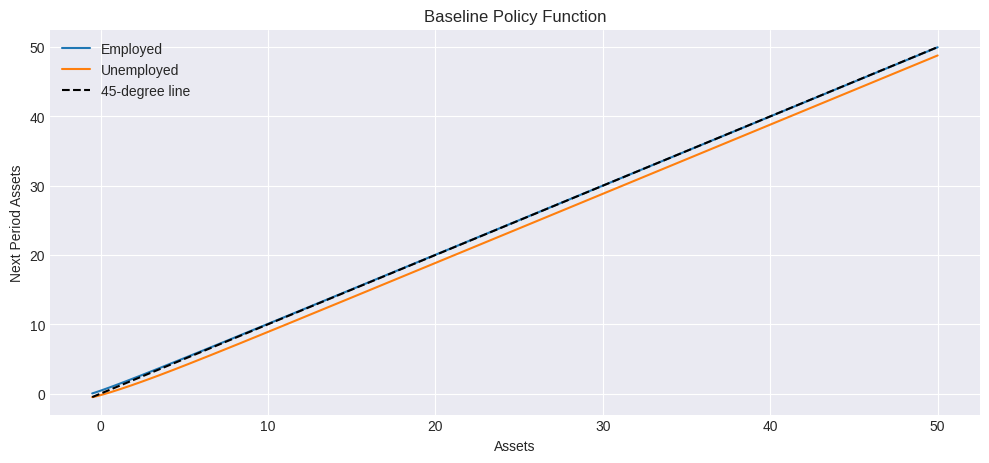

In [96]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(baseline.a_grid, baseline.a_pol[:, 0], label='Employed')
ax.plot(baseline.a_grid, baseline.a_pol[:, 1], label='Unemployed')
ax.plot(baseline.a_grid, baseline.a_grid, 'k--', label='45-degree line')
ax.set_title('Baseline Policy Function')
ax.set_xlabel('Assets')
ax.set_ylabel('Next Period Assets')
ax.legend()
plt.show()

## Baseline interpretation

In line with standard Aiyagari behavior, in the baseline employed households tend to save more than unemployed households because employed households have higher current income and face the risk of future unemployment. Unemployed households draw down assets more often because current income is lower. This is the baseline behavioral margin.

Employed households save to self-insure because they may become unemployed, and unemployed households draw down assets because current income is low.

Only around 8% of households are unemployed and thus get the benefit. A very small portion of the households are borrowing constrained, so this policy is not about relaxing a borrowing constraint.

The asset-tested reform only matters for unemployed households with assets above the threshold. This will make the `asset_test_bite_mass` column meaningful later.

The reform can improve fiscal targeting and lower taxes, but may also weaken self-insurance by making assets reduce future benefit eligibility.

# Part III. Policy Comparative Statics

This section studies the asset-tested benefit schedule in stationary general equilibrium.

The economic question is whether asset testing mainly improves targeting or whether it also weakens self-insurance.

The asset test is shifted here in two ways, varying $\phi_a$ shifts the steepness of how much additional assets decrease the benefit and varying $\bar a$ shifts the threshold at which the means-testing kicks in.

The reform makes the benefit depend on assets:

$$B(a,u)=\max\{0,\ b-\phi_a\max(a-\bar a,0)\}.$$

The experiment has two policy margins. First, I vary the asset phase-out rate $\phi_a$, holding the exempt asset threshold fixed. This changes how steeply benefits are withdrawn once assets exceed the threshold. Second, I vary the exempt asset threshold $\bar a$, holding the phase-out rate fixed. This changes where in the asset distribution the asset test begins to apply.

## Experiment 1: Varying the asset phase-out rate

The first experiment varies the phase-out rate over

$$
\phi_a \in \{0.010,\ 0.025,\ 0.050,\ 0.100\},
$$

while holding the exempt asset threshold fixed at $\bar a=1.0$. The value $\phi_a=0$ reproduces the original benefit rule because benefits do not depend on assets. Higher values of $\phi_a$ make the asset test more severe: each additional unit of assets above the threshold reduces the benefit more strongly.


A phase-out rate of $\phi_a=0.01$ means that each additional unit of assets above the exemption threshold $\bar a$ reduces the benefit by $0.01$, so with $b=0.10$ and $\bar a=1.0$, the benefit is fully phased out at $a=\bar a+\frac{b}{\phi_a}=1.0+\frac{0.10}{0.01}=11.0$.

In [97]:
start = time.time()

phi_a_grid = [0.01, 0.025, 0.05, 0.10]
phi_models = []
phi_summaries = []

prev = baseline

for phi_a in phi_a_grid:
    mod_policy = AiyagariModel(
        K0=prev.K,
        tau0=prev.tau,
        amin=-0.5,
        num_a=2000,
        amax=50.0,
        b=0.1,
        phi_a=phi_a,
        a_thresh=1.0
    )

    if hasattr(prev, "v"):
        mod_policy.v = prev.v.copy()

    solve_general_equilibrium(
        mod_policy,
        damp=0.02,
        tol=1e-3,
        max_iter=200,
        vf_tol=1e-8,
        dist_tol=1e-8,
        verbose=False
    )

    phi_models.append(mod_policy)

    label = f"phi_a={phi_a}"
    phi_summaries.append(summarize_equilibrium(mod_policy, label))

    prev = mod_policy

elapsed = (time.time() - start) / 60
print(f"Elapsed: {elapsed:.2f} min")   
    
phi_table = pd.DataFrame(phi_summaries)
phi_table

Elapsed: 1.88 min


,regime,K,r,w,tau,N,benefit_costs,mass_borrowing,share_receiving_benefit,asset_test_bite_mass,average_asset_test_loss,mass_normalization,market_clearing_residual
0,phi_a=0.01,8.077834,0.049629,1.399100,0.002034,0.919963,0.003242,0.000030,0.070162,0.078663,0.004761,1.0,0.000972
1,phi_a=0.025,8.166387,0.049005,1.404602,0.000664,0.919963,0.000936,0.000035,0.021302,0.078432,0.007068,1.0,0.000970
2,phi_a=0.05,8.203092,0.048750,1.406872,0.000365,0.919963,0.000435,0.000036,0.007868,0.078388,0.007569,1.0,0.000961
3,phi_a=0.1,8.219812,0.048635,1.407904,0.000256,0.919963,0.000275,0.000037,0.003971,0.078357,0.007729,1.0,0.000951


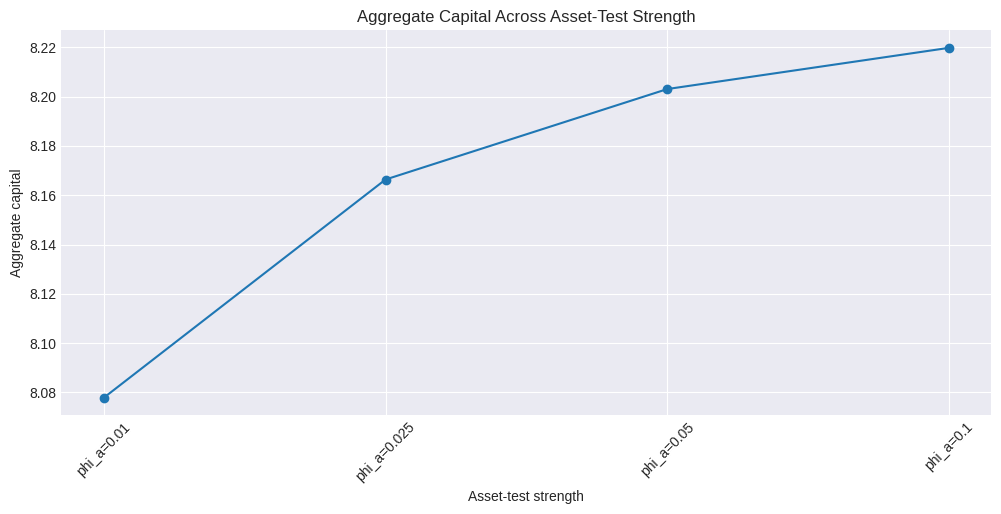

In [98]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(phi_table.loc[phi_table['regime'].str.contains('phi_a'), 'regime'], phi_table.loc[phi_table['regime'].str.contains('phi_a'), 'K'], marker='o')
ax.set_title('Aggregate Capital Across Asset-Test Strength')
ax.set_xlabel('Asset-test strength')
ax.set_ylabel('Aggregate capital')
plt.xticks(rotation=45)
plt.show()

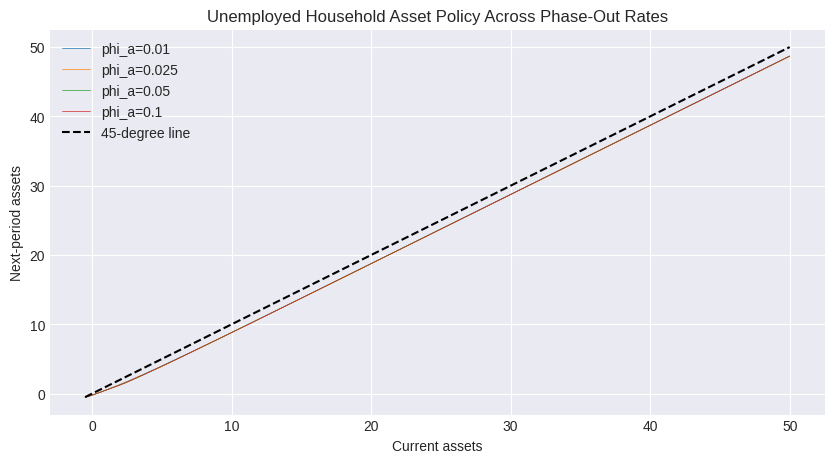

In [99]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

selected_indices = [0, 1, 2, 3]

for idx in selected_indices:
    mod = phi_models[idx]
    label = phi_table.loc[idx, "regime"]
    ax.plot(mod.a_grid, mod.a_pol[:, 1], linewidth=0.5, label=label)

ax.plot(baseline.a_grid, baseline.a_grid, "k--", label="45-degree line")
ax.set_title("Unemployed Household Asset Policy Across Phase-Out Rates")
ax.set_xlabel("Current assets")
ax.set_ylabel("Next-period assets")
ax.legend()

plt.show()

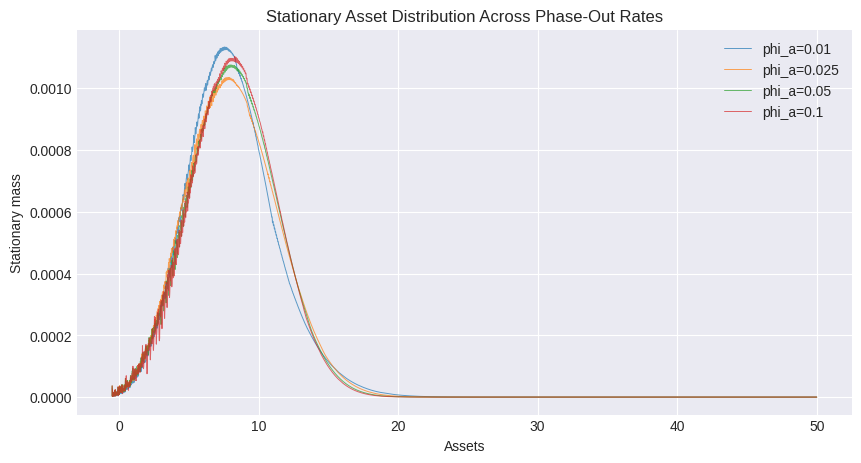

In [100]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for idx in selected_indices:
    mod = phi_models[idx]
    label = phi_table.loc[idx, "regime"]
    density = mod.dist[:, 0] + mod.dist[:, 1]
    ax.plot(mod.dist_grid, density, linewidth=0.7, alpha=0.7, label=label)

ax.set_title("Stationary Asset Distribution Across Phase-Out Rates")
ax.set_xlabel("Assets")
ax.set_ylabel("Stationary mass")
ax.legend()

plt.show()

The phase-out experiment shows how the economy changes as the asset test becomes steeper. The key variables to compare are aggregate capital, the equilibrium tax rate, benefit costs, the mass receiving benefits, and the mass directly affected by the asset test. Aggregate capital accumulation increases as $\phi_a$ increases.

A higher $\phi_a$ reduces benefits for unemployed households with assets above $\bar a$. This lowers benefit spending and therefore tends to reduce the tax rate needed to balance the government budget. In this case, $\tau$ falls by a factor of 8, implying very high savings from the policy change.

The unemployed policy-function figure shows where this margin appears. Since there is no visible shift in the policy functions, the policy is mostly mechanical, not behavioral distortion.

Increasing $\phi_a$ appears to shift the asset distribution to the right, which is likely driven by lower taxes and equilibrium-price changes.

## Experiment 2: Varying the exempt asset threshold

The second experiment fixes the phase-out rate at

$$
\phi_a=0.025
$$

and varies the exempt asset threshold over

$$
\bar a \in \{1.0,\ 2.0,\ 3.0,\ 4.0\}.
$$

This experiment changes how much of the asset distribution is protected from the asset test. A lower threshold means that the benefit withdrawal begins at lower wealth levels and therefore affects more unemployed households. A higher threshold makes the asset test narrower and protects more buffer-stock saving.

The asset threshold $\bar a=1.0$ means that the first $1.0$ units of assets are exempt from the asset test, so with $b=0.10$ and $\phi_a=0.025$, a household with $a=0.5$ or $a=1.0$ receives the full benefit $0.10$, while a household with $a=2.0$ receives $0.10 - 0.025(2.0-1.0)=0.075$.

In [101]:
start = time.time()

a_thresh_grid = [1.0, 2.0, 3.0, 4.0]
thresh_models = []
thresh_summaries = []

prev = baseline

for a_thresh in a_thresh_grid:
    mod_policy = AiyagariModel(
        K0=prev.K,
        tau0=prev.tau,
        amin=-0.5,
        num_a=2000,
        amax=50.0,
        b=0.1,
        phi_a=0.025,
        a_thresh=a_thresh
    )

    if hasattr(prev, "v"):
        mod_policy.v = prev.v.copy()

    solve_general_equilibrium(
        mod_policy,
        damp=0.02,
        tol=1e-3,
        max_iter=200,
        vf_tol=1e-8,
        dist_tol=1e-8,
        verbose=False
    )

    thresh_models.append(mod_policy)
    thresh_summaries.append(summarize_equilibrium(mod_policy, f"a_thresh={a_thresh}"))

    prev = mod_policy

    
elapsed = (time.time() - start) / 60
print(f"Elapsed: {elapsed:.2f} min")
    
thresh_table = pd.DataFrame(thresh_summaries)
thresh_table

Elapsed: 1.86 min


,regime,K,r,w,tau,N,benefit_costs,mass_borrowing,share_receiving_benefit,asset_test_bite_mass,average_asset_test_loss,mass_normalization,market_clearing_residual
0,a_thresh=1.0,8.166377,0.049005,1.404602,0.000665,0.919963,0.000936,0.000035,0.021302,0.078432,0.007068,1.0,0.000979
1,a_thresh=2.0,8.130004,0.049260,1.402346,0.000816,0.919963,0.001567,0.000034,0.031048,0.075881,0.006437,1.0,-0.000962
2,a_thresh=3.0,8.091770,0.049530,1.399969,0.001287,0.919963,0.002361,0.000032,0.041288,0.071686,0.005642,1.0,-0.000961
3,a_thresh=4.0,8.056960,0.049777,1.397797,0.001819,0.919963,0.003261,0.000030,0.051088,0.065673,0.004742,1.0,-0.000977


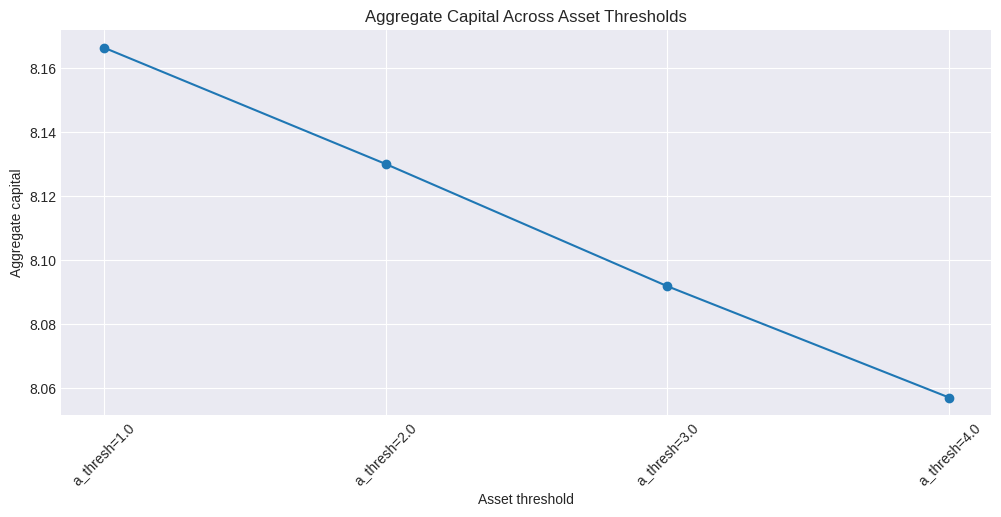

In [102]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(thresh_table.loc[thresh_table['regime'].str.contains('a_thresh'), 'regime'], thresh_table.loc[thresh_table['regime'].str.contains('a_thresh'), 'K'], marker='o')
ax.set_title('Aggregate Capital Across Asset Thresholds')
ax.set_xlabel('Asset threshold')
ax.set_ylabel('Aggregate capital')
plt.xticks(rotation=45)
plt.show()

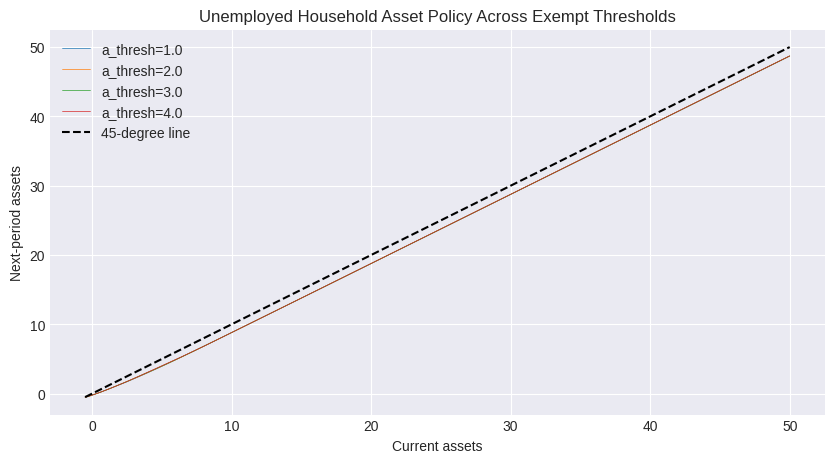

In [103]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

selected_indices_thresh = [0, 1, 2, 3]

for idx in selected_indices_thresh:
    mod = thresh_models[idx]
    label = thresh_table.loc[idx, "regime"]
    ax.plot(mod.a_grid, mod.a_pol[:, 1], linewidth=0.5, label=label)
    
ax.plot(baseline.a_grid, baseline.a_grid, "k--", label="45-degree line")
ax.set_title("Unemployed Household Asset Policy Across Exempt Thresholds")
ax.set_xlabel("Current assets")
ax.set_ylabel("Next-period assets")
ax.legend()

plt.show()

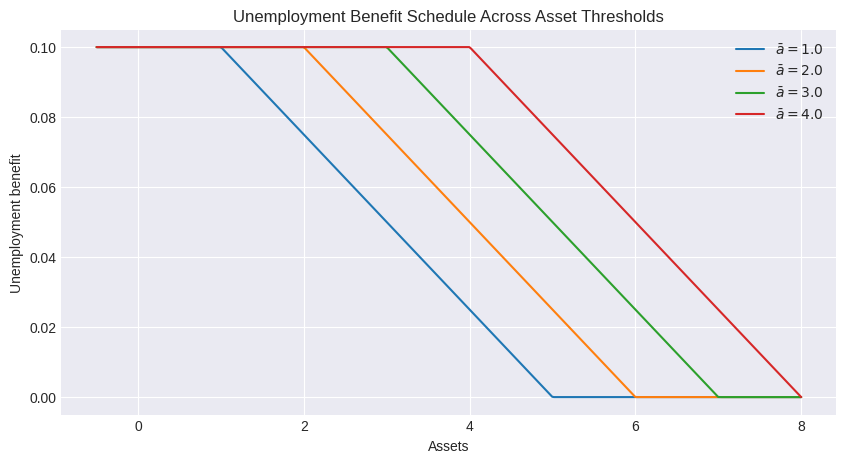

In [104]:
asset_plot_grid = np.linspace(baseline.amin, 8.0, 400)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for a_thresh in a_thresh_grid:
    benefits = np.array([transfer(a, baseline.b, 0.025, a_thresh) for a in asset_plot_grid])
    ax.plot(asset_plot_grid, benefits, label=rf"$\bar a={a_thresh}$")

ax.set_title("Unemployment Benefit Schedule Across Asset Thresholds")
ax.set_xlabel("Assets")
ax.set_ylabel("Unemployment benefit")
ax.legend()

plt.show()

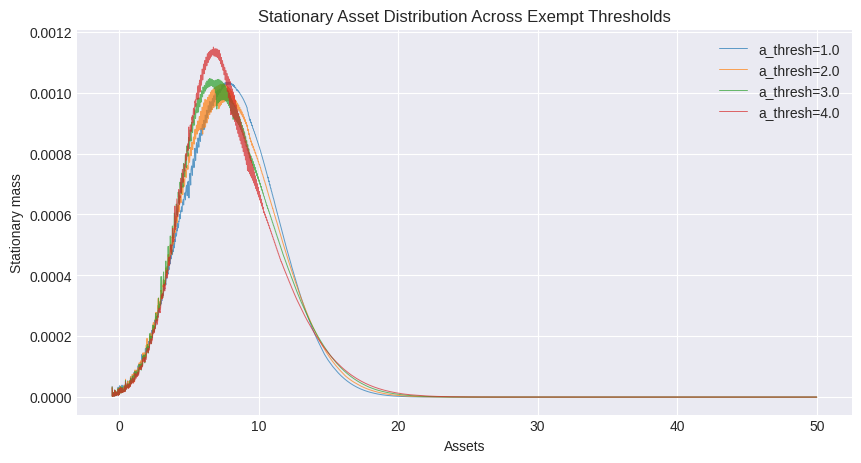

In [105]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for idx in selected_indices_thresh:
    mod = thresh_models[idx]
    label = thresh_table.loc[idx, "regime"]
    density = mod.dist[:, 0] + mod.dist[:, 1]
    ax.plot(mod.dist_grid, density, linewidth=0.7, alpha=0.7, label=label)

ax.set_title("Stationary Asset Distribution Across Exempt Thresholds")
ax.set_xlabel("Assets")
ax.set_ylabel("Stationary mass")
ax.legend()

plt.show()

The threshold experiment separates the intensive and extensive margins of asset testing. Holding $\phi_a$ fixed, a lower $\bar a$ means that more unemployed households face benefit withdrawal. In this case, aggregate capital accumulation decreases as $\bar a$ increases.

Varying $\bar a$ changes which households are exposed to the allowance. Increasing $\bar a$ means that more households get more of the benefit, which increases the tax rate needed to finance the program. Indeed, $\tau$ almost triples from 0.000663 to 0.001819, a significant change.

Increasing $\bar a$ shifts the asset distribution slightly to the left, while the policy-function plots again show little visible movement. Therefore, the main result should not be described as a large direct policy-function response. Instead, the threshold mainly changes program generosity and the tax burden.

### Conclusion

In both cases here, government costs and thus tax rates $\tau$ are hugely impacted (by a factor of 8 and 3, respectively) while policy functions and the stationary distribution don't move that much. 

Overall, the comparative statics suggest that the asset test mainly changes benefit targeting and fiscal costs, while savings motive responses are modest but real. Therefore, targeting the policy seems to work well for the fiscal target with tolerable negative welfare effects on saving policies of households. 

This matches the stated target of the Orpo government to cut government spending by cutting the housing allowance.

# Part IV. Policy Evaluation and Discussion

The policy experiments ask whether asset-testing benefits improves targeting enough to offset the savings distortion it creates.

When the phase-out rate is increased, the government saves on benefits and the equilibrium tax rate falls. When the asset threshold is increased and more households remain eligible for benefits, program costs and taxes rise, and aggregate capital falls.

Low-asset unemployed households remain insured because they continue to receive the full benefit post-reform. Unemployed households above the threshold lose some or all benefits. Employed households are also affected through equilibrium changes in taxes, wages, and interest rates. 

### Consumption-equivalent welfare

A positive CEV value means that the policy economy is preferred to the baseline economy. A negative value means that the policy economy is worse than the baseline economy in lifetime utility terms.


The period utility function used in the code is

$$u(c)=\frac{c^{1-\eta}-1}{1-\eta},
\qquad \eta \neq 1.$$

In [106]:
def value_to_consumption_power(V, beta, eta):
    return (1.0 - eta) * V + 1.0 / (1.0 - beta)


def interpolate_value_to_grid(mod, target_grid):
    out = np.empty((len(target_grid), 2))
    out[:, 0] = np.interp(target_grid, mod.a_grid, mod.v[:, 0])
    out[:, 1] = np.interp(target_grid, mod.a_grid, mod.v[:, 1])
    return out


def cev_from_values(V_base, V_policy, beta, eta):
    A_base = value_to_consumption_power(V_base, beta, eta)
    A_policy = value_to_consumption_power(V_policy, beta, eta)
    ratio = A_policy / A_base
    cev = ratio ** (1.0 / (1.0 - eta)) - 1.0
    return cev


def weighted_average(x, weights):
    return np.sum(x * weights) / np.sum(weights)


def compute_cev_against_baseline(baseline, policy_mod, label):
    grid = baseline.dist_grid
    weights = baseline.dist
    V_base = interpolate_value_to_grid(baseline, grid)
    V_policy = interpolate_value_to_grid(policy_mod, grid)
    cev = cev_from_values(V_base, V_policy, baseline.beta, baseline.eta)

    assets = grid[:, None]
    low_assets = assets <= baseline.a_thresh
    high_assets = assets > baseline.a_thresh

    employed_weights = weights[:, 0]
    unemployed_weights = weights[:, 1]

    total_weights = weights
    low_weights = weights * low_assets
    high_weights = weights * high_assets

    return {
        "regime": label,
        "cev_mean_pct": 100.0 * weighted_average(cev, total_weights),
        "cev_employed_pct": 100.0 * weighted_average(cev[:, 0], employed_weights),
        "cev_unemployed_pct": 100.0 * weighted_average(cev[:, 1], unemployed_weights),
        "cev_low_asset_pct": 100.0 * weighted_average(cev, low_weights),
        "cev_high_asset_pct": 100.0 * weighted_average(cev, high_weights),
        "cev_p10_pct": 100.0 * np.quantile(cev.reshape(-1), 0.10),
        "cev_p50_pct": 100.0 * np.quantile(cev.reshape(-1), 0.50),
        "cev_p90_pct": 100.0 * np.quantile(cev.reshape(-1), 0.90)
    }


def stationary_welfare(mod):
    V_on_dist_grid = interpolate_value_to_grid(mod, mod.dist_grid)
    return np.sum(mod.dist * V_on_dist_grid)


def add_stationary_welfare(table, models):
    out = table.copy()
    out["stationary_welfare"] = [stationary_welfare(m) for m in models]
    return out

### CEV table and figures for variation in $\phi_a$

In [107]:
phi_cev_rows = []

for i, mod in enumerate(phi_models):
    label = phi_table.loc[i, "regime"]
    phi_cev_rows.append(compute_cev_against_baseline(baseline, mod, label))

phi_cev_table = pd.DataFrame(phi_cev_rows)

phi_eval_table = phi_table.merge(phi_cev_table, on="regime")
phi_eval_table = add_stationary_welfare(phi_eval_table, phi_models)

phi_eval_table[
    [
        "regime",
        "K",
        "r",
        "w",
        "tau",
        "benefit_costs",
        "share_receiving_benefit",
        "asset_test_bite_mass",
        "average_asset_test_loss",
        "cev_mean_pct",
        "cev_employed_pct",
        "cev_unemployed_pct",
        "cev_low_asset_pct",
        "cev_high_asset_pct",
        "cev_p10_pct",
        "cev_p50_pct",
        "cev_p90_pct",
        "stationary_welfare"
    ]
]

,regime,K,r,w,tau,benefit_costs,share_receiving_benefit,asset_test_bite_mass,average_asset_test_loss,cev_mean_pct,cev_employed_pct,cev_unemployed_pct,cev_low_asset_pct,cev_high_asset_pct,cev_p10_pct,cev_p50_pct,cev_p90_pct,stationary_welfare
0,phi_a=0.01,8.077834,0.049629,1.399100,0.002034,0.003242,0.070162,0.078663,0.004761,-0.071341,-0.047433,-0.346146,-0.005453,-0.082269,-0.441038,-0.016989,0.267888,7.905001
1,phi_a=0.025,8.166387,0.049005,1.404602,0.000664,0.000936,0.021302,0.078432,0.007068,-0.132093,-0.090378,-0.611570,-0.024091,-0.150006,-0.623460,-0.180690,-0.098386,7.922808
2,phi_a=0.05,8.203092,0.048750,1.406872,0.000365,0.000435,0.007868,0.078388,0.007569,-0.160432,-0.109411,-0.746882,-0.122451,-0.166732,-0.685044,-0.411013,-0.108915,7.940068
3,phi_a=0.1,8.219812,0.048635,1.407904,0.000256,0.000275,0.003971,0.078357,0.007729,-0.175698,-0.119433,-0.822417,-0.180059,-0.174974,-0.776087,-0.520390,-0.114038,7.948573


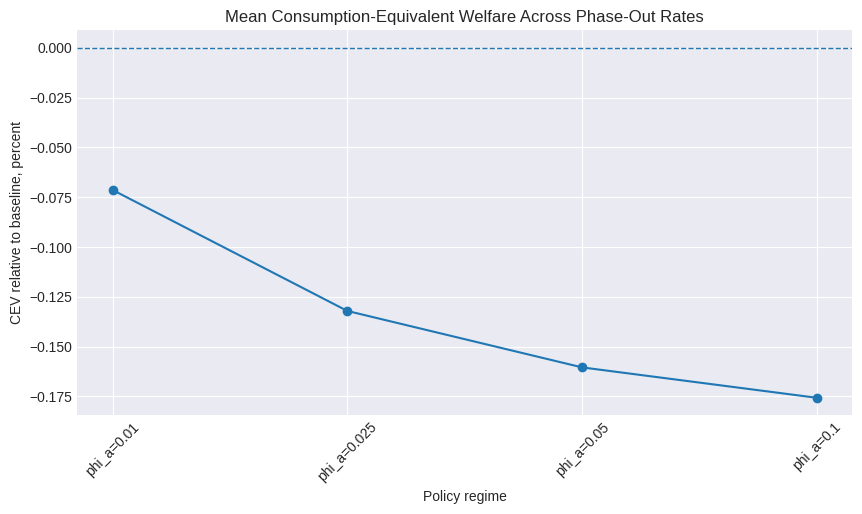

In [108]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(phi_eval_table["regime"], phi_eval_table["cev_mean_pct"], marker="o")
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_title("Mean Consumption-Equivalent Welfare Across Phase-Out Rates")
ax.set_xlabel("Policy regime")
ax.set_ylabel("CEV relative to baseline, percent")
plt.xticks(rotation=45)
plt.show()

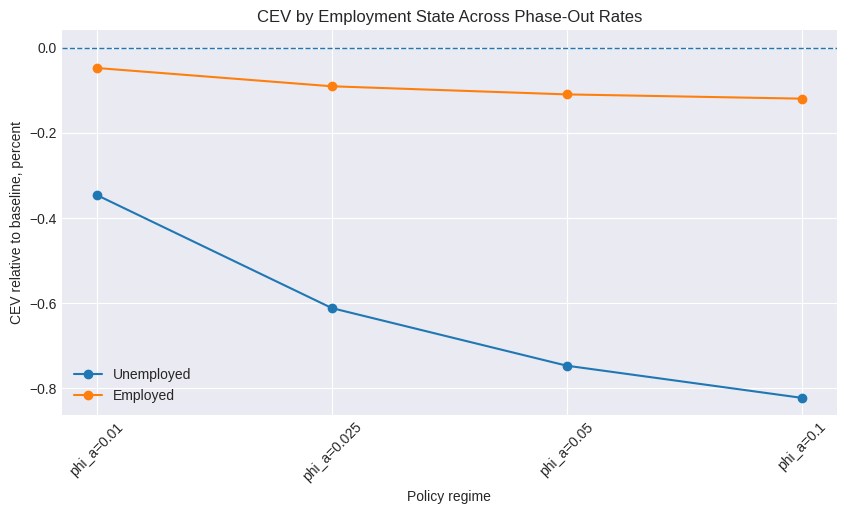

In [109]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(phi_eval_table["regime"], phi_eval_table["cev_unemployed_pct"], marker="o", label="Unemployed")
ax.plot(phi_eval_table["regime"], phi_eval_table["cev_employed_pct"], marker="o", label="Employed")
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_title("CEV by Employment State Across Phase-Out Rates")
ax.set_xlabel("Policy regime")
ax.set_ylabel("CEV relative to baseline, percent")
ax.legend()
plt.xticks(rotation=45)
plt.show()

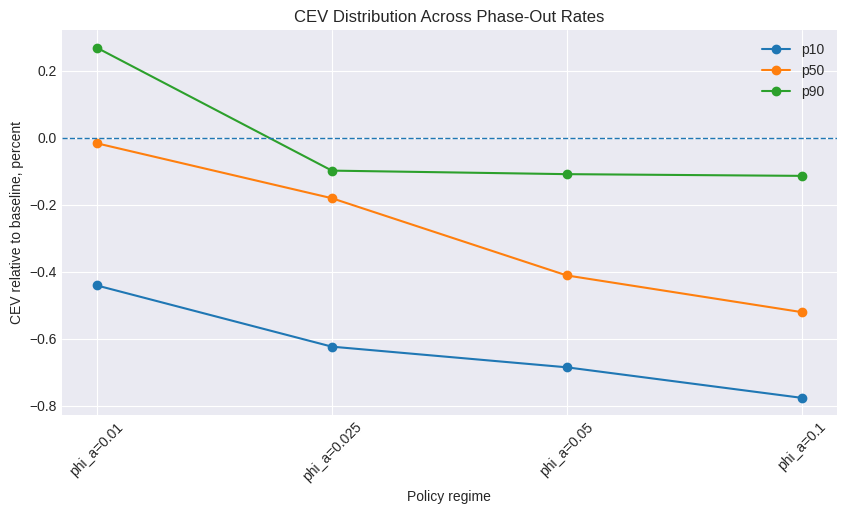

In [110]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(phi_eval_table["regime"], phi_eval_table["cev_p10_pct"], marker="o", label="p10")
ax.plot(phi_eval_table["regime"], phi_eval_table["cev_p50_pct"], marker="o", label="p50")
ax.plot(phi_eval_table["regime"], phi_eval_table["cev_p90_pct"], marker="o", label="p90")

ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_title("CEV Distribution Across Phase-Out Rates")
ax.set_xlabel("Policy regime")
ax.set_ylabel("CEV relative to baseline, percent")
ax.legend()
plt.xticks(rotation=45)
plt.show()

On average, the CEV effects appear to be negative for aggregate households, and for both employed and unemployed households. This is because the **reform weakens insurance and taxes precautionary savings**.

In the case of a very small phase-out rate ($\phi_a = 0.01$), the richest households (90th percentile) slightly benefit more than in the base case, equivalent to giving them around +0.2% in consumption. This is likely because high-asset households benefit from the lower taxes and/or favorable price changes for them.

This illustrates the central distributional trade-off. The reform keeps protecting low-asset unemployed households and reduces transfers to asset-rich unemployed households, but it can also reduce welfare by making insurance less complete. This mechanism of incomplete insurance sits at the heart of the Aiyagari model.

### CEV table and figures for variation in $\bar a$

In [111]:
thresh_cev_rows = []

for i, mod in enumerate(thresh_models):
    label = thresh_table.loc[i, "regime"]
    thresh_cev_rows.append(compute_cev_against_baseline(baseline, mod, label))

thresh_cev_table = pd.DataFrame(thresh_cev_rows)

thresh_eval_table = thresh_table.merge(thresh_cev_table, on="regime")
thresh_eval_table = add_stationary_welfare(thresh_eval_table, thresh_models)

thresh_eval_table[
    [
        "regime",
        "K",
        "r",
        "w",
        "tau",
        "benefit_costs",
        "share_receiving_benefit",
        "asset_test_bite_mass",
        "average_asset_test_loss",
        "cev_mean_pct",
        "cev_employed_pct",
        "cev_unemployed_pct",
        "cev_low_asset_pct",
        "cev_high_asset_pct",
        "cev_p10_pct",
        "cev_p50_pct",
        "cev_p90_pct",
        "stationary_welfare"
    ]
]

,regime,K,r,w,tau,benefit_costs,share_receiving_benefit,asset_test_bite_mass,average_asset_test_loss,cev_mean_pct,cev_employed_pct,cev_unemployed_pct,cev_low_asset_pct,cev_high_asset_pct,cev_p10_pct,cev_p50_pct,cev_p90_pct,stationary_welfare
0,a_thresh=1.0,8.166377,0.049005,1.404602,0.000665,0.000936,0.021302,0.078432,0.007068,-0.132200,-0.090486,-0.611674,-0.024214,-0.150111,-0.623568,-0.180729,-0.098498,7.922794
1,a_thresh=2.0,8.130004,0.049260,1.402346,0.000816,0.001567,0.031048,0.075881,0.006437,-0.084783,-0.051801,-0.463891,0.078994,-0.111948,-0.538318,-0.082693,0.065032,7.908079
2,a_thresh=3.0,8.091770,0.049530,1.399969,0.001287,0.002361,0.041288,0.071686,0.005642,-0.063856,-0.038328,-0.357276,0.115352,-0.093580,-0.471037,-0.000458,0.249946,7.893321
3,a_thresh=4.0,8.056960,0.049777,1.397797,0.001819,0.003261,0.051088,0.065673,0.004742,-0.045408,-0.026015,-0.268321,0.109992,-0.071183,-0.403650,0.102679,0.426420,7.884098


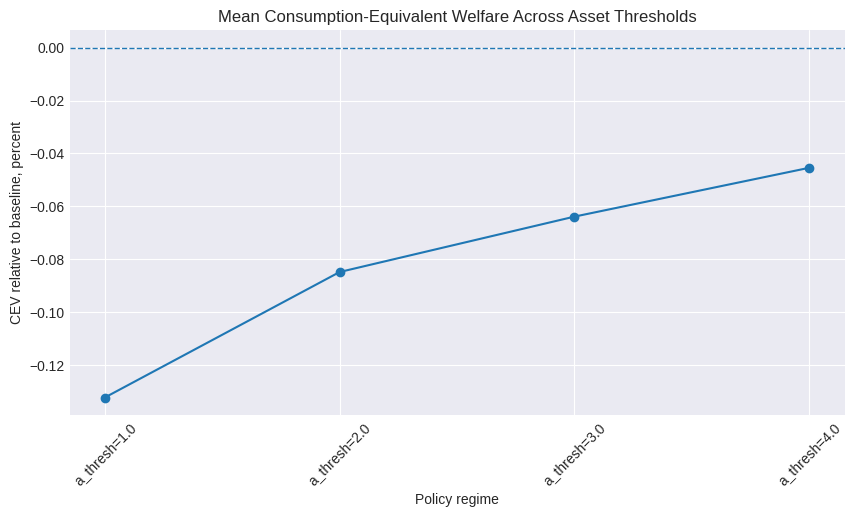

In [112]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(thresh_eval_table["regime"], thresh_eval_table["cev_mean_pct"], marker="o")
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_title("Mean Consumption-Equivalent Welfare Across Asset Thresholds")
ax.set_xlabel("Policy regime")
ax.set_ylabel("CEV relative to baseline, percent")
plt.xticks(rotation=45)
plt.show()

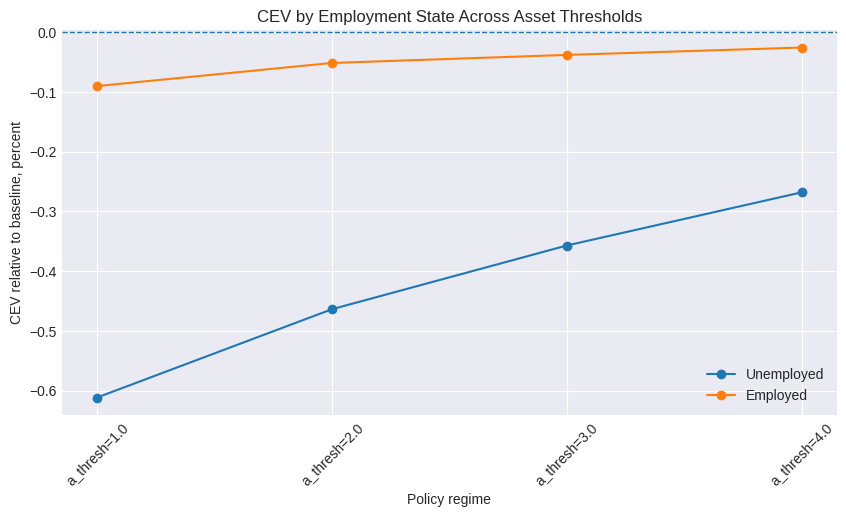

In [113]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(thresh_eval_table["regime"], thresh_eval_table["cev_unemployed_pct"], marker="o", label="Unemployed")
ax.plot(thresh_eval_table["regime"], thresh_eval_table["cev_employed_pct"], marker="o", label="Employed")
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_title("CEV by Employment State Across Asset Thresholds")
ax.set_xlabel("Policy regime")
ax.set_ylabel("CEV relative to baseline, percent")
ax.legend()
plt.xticks(rotation=45)
plt.show()

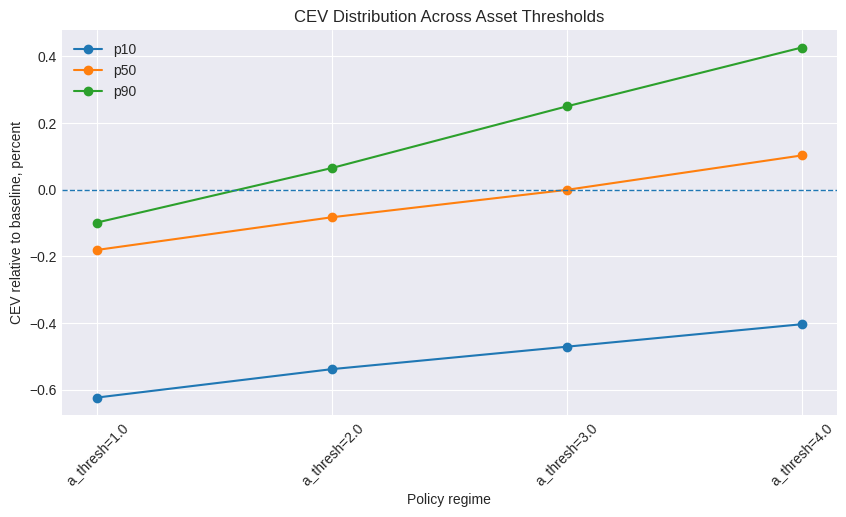

In [114]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(thresh_eval_table["regime"], thresh_eval_table["cev_p10_pct"], marker="o", label="p10")
ax.plot(thresh_eval_table["regime"], thresh_eval_table["cev_p50_pct"], marker="o", label="p50")
ax.plot(thresh_eval_table["regime"], thresh_eval_table["cev_p90_pct"], marker="o", label="p90")

ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_title("CEV Distribution Across Asset Thresholds")
ax.set_xlabel("Policy regime")
ax.set_ylabel("CEV relative to baseline, percent")
ax.legend()
plt.xticks(rotation=45)
plt.show()

On average, the CEV effects are also negative for the asset thresholds, although this appears to be diminishing as the asset threshold is raised, for both employed and unemployed households. The negative CEV values suggest that the **insurance loss dominates the fiscal savings for the average household**.

However, the richest households (90th percentile) benefit from increasing the threshold relative to the baseline. This might be because raising the asset threshold makes the asset test less punitive for richer households despite the program becoming more expensive to finance with taxes.

### Limitations and conclusion

First, the policy is a stylized asset-tested benefit rather than a full model of the Finnish housing allowance model. A full model would also consider effects on housing markets and the fact that the Orpo government reform actually allows for savings in housing (ASP account) without reducing the housing allowance, for instance.

Labor supply and job search are not endogenous. Unemployment risk is taken as given, so households cannot respond to reforms by changing search effort or participation. This is unrealistic, since the level of the benefit and assets would almost certainly also affect these margins.

Lastly, a numerical limitation in my simulations is that the visible policy-function responses are very small, which causes variation to come from changes in prices and taxes. 

Based on these findings, asset-tested fiscal targeting of insurance does **not** come at the cost of broad changes in savings habits, but it does come with other distributional and aggregate concerns.

However, results should be interpreted qualitatively rather than as precise policy estimates. Further and more precise analysis can potentially be a part of my doctoral dissertation on housing markets and urban economis. This would likely involve calibrating the model more carefully using Finnish microdata.

# Part V. Numerical Credibility and Reproducibility

### Diagnostics

Diagnostic table in the appendix.

The stationary distribution integrates to one in all regimes and market-clearing residuals are small, which implies the model converges well at different values

The mass at the borrowing constraint is also very small, around 0.003 percent of households. Thus, the arbitrary lower asset bound does not appear to be driving policy results.

The mass at the upper grid point is zero in all regimes, which suggests that the asset grid is wide enough to capture everything and that the upper bound is not truncating the wealth distribution. 

Finally, the asset policy functions are monotone for both employed and unemployed households in every regime.

The code passes these checks, but I would still encourage caution in making policy based on these findings.

### Replication

Reproduction follows the order of the notebook.

The main items needed to reproduce the results are `baseline`, `phi_models`, `thresh_models`, `phi_table`, `thresh_table`, `phi_eval_table`, and `thresh_eval_table`.

All tables and figures are produced by running the notebook top to bottom after imports.

### AI DISCLOSURE

I used ChatGPT to help code a version of the Aiyagari model implementation which takes into account both $K$ and $\tau$ in determining convergence in the "solve_general_equilibrium" function, as this turned out to be a bit too difficult for just myself.

Additionally, I used ChatGPT to write the equations into Markdown format since that is quite tedious to do manually.

### REFERENCES

Aiyagari, S. Rao. "Uninsured idiosyncratic risk and aggregate saving." The Quarterly Journal of Economics 109, no. 3 (1994): 659-684.

Sallinen, Minttu. 2025. “Changes to Housing Allowance in 2025 – Means Testing and Changes to Municipal Categories Affect Many Recipients.” PAM, February 14, 2025. https://www.pam.fi/en/stories/changes-to-housing-allowance-in-2025-means-testing-and-changes-to-municipal-categories-affect-many-recipients/

### APPENDIX

First, the stationary distribution should obviously integrate to one. 

Second, the market-clearing residual should be close to zero relative to aggregate capital. 

Third, the mass at the borrowing constraint helps assess whether the lower asset bound is economically important. 

Fourth, the mass at the upper asset-grid point checks whether the asset grid is too short.

In [115]:
def policy_shape_checks(mod):
    return {
        "monotone_employed": np.all(np.diff(mod.a_pol[:, 0]) >= -1e-8),
        "monotone_unemployed": np.all(np.diff(mod.a_pol[:, 1]) >= -1e-8),
        "upper_grid_mass": mod.dist[-1, :].sum(),
        "lower_grid_mass": mod.dist[0, :].sum()
    }

diagnostic_models = [baseline] + phi_models + thresh_models
diagnostic_labels = ["baseline"] + list(phi_table["regime"]) + list(thresh_table["regime"])

diagnostic_rows = []

for label, mod in zip(diagnostic_labels, diagnostic_models):
    eq = summarize_equilibrium(mod, label)
    checks = policy_shape_checks(mod)
    diagnostic_rows.append({
        "regime": label,
        "mass_normalization": eq["mass_normalization"],
        "market_clearing_residual": eq["market_clearing_residual"],
        "abs_market_clearing_residual": abs(eq["market_clearing_residual"]),
        "relative_market_clearing_residual": abs(eq["market_clearing_residual"]) / abs(eq["K"]),
        "mass_borrowing": eq["mass_borrowing"],
        "lower_grid_mass": checks["lower_grid_mass"],
        "upper_grid_mass": checks["upper_grid_mass"],
        "monotone_employed": checks["monotone_employed"],
        "monotone_unemployed": checks["monotone_unemployed"]
    })

diagnostic_table = pd.DataFrame(diagnostic_rows)
diagnostic_table

,regime,mass_normalization,market_clearing_residual,abs_market_clearing_residual,relative_market_clearing_residual,mass_borrowing,lower_grid_mass,upper_grid_mass,monotone_employed,monotone_unemployed
0,baseline,1.0,-0.000379,0.000379,0.000047,0.000025,0.000025,0.0,True,True
1,phi_a=0.01,1.0,0.000972,0.000972,0.000120,0.000030,0.000030,0.0,True,True
2,phi_a=0.025,1.0,0.000970,0.000970,0.000119,0.000035,0.000035,0.0,True,True
3,phi_a=0.05,1.0,0.000961,0.000961,0.000117,0.000036,0.000036,0.0,True,True
4,phi_a=0.1,1.0,0.000951,0.000951,0.000116,0.000037,0.000037,0.0,True,True
5,a_thresh=1.0,1.0,0.000979,0.000979,0.000120,0.000035,0.000035,0.0,True,True
6,a_thresh=2.0,1.0,-0.000962,0.000962,0.000118,0.000034,0.000034,0.0,True,True
7,a_thresh=3.0,1.0,-0.000961,0.000961,0.000119,0.000032,0.000032,0.0,True,True
8,a_thresh=4.0,1.0,-0.000977,0.000977,0.000121,0.000030,0.000030,0.0,True,True


The stationary distribution integrates to one in all regimes and market-clearing residuals are small, which implies the model converges well at different values

The mass at the borrowing constraint is also very small, around 0.003 percent of households. Thus, the arbitrary lower asset bound does not appear to be driving policy results.

The mass at the upper grid point is zero in all regimes, which suggests that the asset grid is wide enough to capture everything and that the upper bound is not truncating the wealth distribution.

Finally, the asset policy functions are monotone for both employed and unemployed households in every regime.

The code passes these checks, but I would still encourage caution in making policy based on these findings.